# 07 - LSTM Model (Daily Sequences)

**Approach:**
- Daily feature sequences (60-day lookback) instead of monthly
- 3-class moneyness target (ATM/OTM5/OTM10) -- consistent with 06b/06c
- Time-based train/test split (no random sampling)
- Class weights for imbalance
- Bidirectional LSTM with temporal attention
- ~52K daily rows give the LSTM far more temporal signal than 1.4K monthly rows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

UNIVERSE = ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

print(f"Device: {device}")

Device: mps


## 1. Compute Daily Features

In [2]:
# Load daily prices
daily = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
daily = daily[daily['symbol'].isin(UNIVERSE)].copy()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['symbol', 'date']).reset_index(drop=True)

print(f"Daily prices: {daily.shape}")

def compute_daily_features(df):
    df = df.copy().sort_values('date')

    # Returns
    df['daily_return'] = df['adjusted_close'].pct_change()

    # Volatility at multiple horizons
    df['vol_5d'] = df['daily_return'].rolling(5).std() * np.sqrt(252)
    df['vol_21d'] = df['daily_return'].rolling(21).std() * np.sqrt(252)
    df['vol_63d'] = df['daily_return'].rolling(63).std() * np.sqrt(252)

    # Momentum
    df['mom_5d'] = df['adjusted_close'].pct_change(5)
    df['mom_21d'] = df['adjusted_close'].pct_change(21)
    df['mom_63d'] = df['adjusted_close'].pct_change(63)

    # Moving averages
    df['sma_21d'] = df['adjusted_close'].rolling(21).mean()
    df['sma_50d'] = df['adjusted_close'].rolling(50).mean()
    df['sma_200d'] = df['adjusted_close'].rolling(200).mean()

    # Price relative to SMAs
    df['price_to_sma21'] = df['adjusted_close'] / df['sma_21d']
    df['price_to_sma50'] = df['adjusted_close'] / df['sma_50d']
    df['price_to_sma200'] = df['adjusted_close'] / df['sma_200d']

    # Drawdowns
    df['rolling_max_63d'] = df['adjusted_close'].rolling(63).max()
    df['drawdown_63d'] = (df['adjusted_close'] - df['rolling_max_63d']) / df['rolling_max_63d']
    df['rolling_max_252d'] = df['adjusted_close'].rolling(252).max()
    df['drawdown_252d'] = (df['adjusted_close'] - df['rolling_max_252d']) / df['rolling_max_252d']

    # Volume
    df['volume_sma_21d'] = df['volume'].rolling(21).mean()
    df['volume_ratio'] = df['volume'] / df['volume_sma_21d']

    # RSI (14-day)
    delta = df['daily_return'].copy()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df['rsi_14'] = 100 - (100 / (1 + rs))

    # Bollinger band width
    df['bb_width'] = (df['adjusted_close'].rolling(21).std() * 2) / df['sma_21d']

    return df

daily_feat = daily.groupby('symbol', group_keys=False).apply(compute_daily_features)

# Drop helper columns
drop_cols = ['open', 'high', 'low', 'close', 'adjusted_close', 'volume', 'dividend',
             'split_coefficient', 'sma_21d', 'sma_50d', 'sma_200d',
             'rolling_max_63d', 'rolling_max_252d', 'volume_sma_21d']
daily_feat = daily_feat.drop(columns=[c for c in drop_cols if c in daily_feat.columns])

feature_cols = [c for c in daily_feat.columns if c not in ['symbol', 'date']]
print(f"Daily features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"Shape: {daily_feat.shape}")

Daily prices: (52486, 10)
Daily features: 15
Features: ['daily_return', 'vol_5d', 'vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma50', 'price_to_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'rsi_14', 'bb_width']
Shape: (52486, 17)


In [3]:
# Forward-fill fundamentals to daily frequency
income = pd.read_parquet(PROCESSED / 'income_clean.parquet')
balance = pd.read_parquet(PROCESSED / 'balance_clean.parquet')

income = income[income['symbol'].isin(UNIVERSE)].copy()
balance = balance[balance['symbol'].isin(UNIVERSE)].copy()

# Key fundamental ratios
fund = income[['symbol', 'fiscalDateEnding', 'grossProfit', 'totalRevenue', 'operatingIncome', 'netIncome']].merge(
    balance[['symbol', 'fiscalDateEnding', 'totalAssets', 'totalShareholderEquity']], 
    on=['symbol', 'fiscalDateEnding'], how='outer'
).sort_values(['symbol', 'fiscalDateEnding'])

fund['gross_margin'] = fund['grossProfit'] / fund['totalRevenue'].replace(0, np.nan)
fund['net_margin'] = fund['netIncome'] / fund['totalRevenue'].replace(0, np.nan)
fund['roe'] = fund['netIncome'] / fund['totalShareholderEquity'].replace(0, np.nan)

fund_cols = ['gross_margin', 'net_margin', 'roe']
fund = fund[['symbol', 'fiscalDateEnding'] + fund_cols].copy()
fund['fiscalDateEnding'] = pd.to_datetime(fund['fiscalDateEnding'])

# Merge asof: for each daily row, get most recent fundamental data
daily_feat = daily_feat.sort_values(['symbol', 'date'])
merged_parts = []
for sym in UNIVERSE:
    d = daily_feat[daily_feat['symbol'] == sym].sort_values('date')
    f = fund[fund['symbol'] == sym].sort_values('fiscalDateEnding')
    m = pd.merge_asof(d, f[['fiscalDateEnding'] + fund_cols], left_on='date', right_on='fiscalDateEnding', direction='backward')
    merged_parts.append(m)
daily_feat = pd.concat(merged_parts, ignore_index=True)
daily_feat = daily_feat.drop(columns=['fiscalDateEnding'], errors='ignore')

feature_cols = [c for c in daily_feat.columns if c not in ['symbol', 'date']]
print(f"Features after fundamentals: {len(feature_cols)}")
print(f"Shape: {daily_feat.shape}")

Features after fundamentals: 18
Shape: (52486, 20)


## 2. Create Labels and Sequences

In [4]:
# Load monthly labels (3-class moneyness)
modeling = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
modeling['decision_date'] = pd.to_datetime(modeling['decision_date'])
modeling['moneyness'] = modeling['best_bucket'].str.extract(r'(ATM|OTM5|OTM10)')[0]
moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
modeling['label_3'] = modeling['moneyness'].map(moneyness_map)

# Labels at monthly decision points
labels = modeling[['symbol', 'decision_date', 'label_3']].copy()
print(f"Monthly labels: {len(labels)}")
print(f"Label distribution:")
print(labels['label_3'].value_counts().sort_index())

Monthly labels: 1391
Label distribution:
label_3
0    685
1    362
2    344
Name: count, dtype: int64


In [5]:
SEQ_LENGTH = 60  # 60 trading days (~3 months)

def create_daily_sequences(daily_feat, labels, feature_cols, seq_length):
    """
    For each monthly decision point, take the prior seq_length daily rows as input.
    Label comes from the monthly decision point.
    """
    X_seq, y_seq, dates_seq = [], [], []
    
    # Fill NaN in features
    daily_feat[feature_cols] = daily_feat[feature_cols].fillna(method='ffill')
    daily_feat[feature_cols] = daily_feat[feature_cols].fillna(0)
    
    for _, label_row in labels.iterrows():
        sym = label_row['symbol']
        dec_date = label_row['decision_date']
        label = label_row['label_3']
        
        # Get daily data for this ticker up to decision date
        sym_daily = daily_feat[
            (daily_feat['symbol'] == sym) & (daily_feat['date'] <= dec_date)
        ].sort_values('date')
        
        if len(sym_daily) < seq_length:
            continue
        
        # Take last seq_length days
        seq_data = sym_daily[feature_cols].values[-seq_length:]
        X_seq.append(seq_data)
        y_seq.append(label)
        dates_seq.append(dec_date)
    
    return np.array(X_seq), np.array(y_seq), np.array(dates_seq)

X_all, y_all, dates_all = create_daily_sequences(daily_feat, labels, feature_cols, SEQ_LENGTH)
print(f"Sequences: {X_all.shape}  (samples, {SEQ_LENGTH} days, {len(feature_cols)} features)")
print(f"Labels: {y_all.shape}")
print(f"Date range: {pd.Timestamp(dates_all.min()).date()} to {pd.Timestamp(dates_all.max()).date()}")

Sequences: (1389, 60, 18)  (samples, 60 days, 18 features)
Labels: (1389,)
Date range: 2008-02-29 to 2025-12-31


## 3. Time-Based Split

In [6]:
# Split at 80th percentile date (same as 06b)
unique_dates = np.sort(np.unique(dates_all))
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = dates_all < split_date
test_mask = dates_all >= split_date

X_train_raw = X_all[train_mask]
X_test_raw = X_all[test_mask]
y_train = y_all[train_mask]
y_test = y_all[test_mask]
dates_test = dates_all[test_mask]

# Scale using ONLY training data
n_train, seq_len, n_feat = X_train_raw.shape
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_sc = scaler.transform(X_test_raw.reshape(-1, n_feat)).reshape(len(X_test_raw), seq_len, n_feat)

print(f"Split date: {pd.Timestamp(split_date).date()}")
print(f"Train: {n_train} sequences")
print(f"Test:  {len(X_test_raw)} sequences")
print(f"\nTrain label dist: {np.bincount(y_train)}")
print(f"Test label dist:  {np.bincount(y_test)}")

Split date: 2022-06-30
Train: 1010 sequences
Test:  379 sequences

Train label dist: [524 290 196]
Test label dist:  [161  71 147]


## 4. LSTM with Temporal Attention

In [7]:
class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=True):
        super().__init__()
        self.directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_out_size = hidden_size * self.directions

        self.attention = nn.Sequential(
            nn.Linear(lstm_out_size, lstm_out_size // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_size // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)
        return self.classifier(context)

# Count params
model_test = AttentionLSTM(n_feat, 64, 2, 3, dropout=0.3)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"AttentionLSTM defined")
print(f"Parameters: {n_params:,} (hidden=64, layers=2, bidirectional)")

AttentionLSTM defined
Parameters: 159,108 (hidden=64, layers=2, bidirectional)


## 5. Training

In [8]:
def train_lstm(X_train_sc, X_test_sc, y_train, y_test, num_classes,
               hidden_size=64, num_layers=2, dropout=0.3, lr=0.001,
               epochs=100, patience=15, batch_size=64, verbose=True):

    train_ds = TensorDataset(torch.FloatTensor(X_train_sc), torch.LongTensor(y_train))
    test_ds = TensorDataset(torch.FloatTensor(X_test_sc), torch.LongTensor(y_test))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    model = AttentionLSTM(
        input_size=X_train_sc.shape[2], hidden_size=hidden_size,
        num_layers=num_layers, num_classes=num_classes, dropout=dropout
    ).to(device)

    # Class weights
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.sum() * num_classes
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(weights).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_f1, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['train_acc'].append(correct / total)

        model.eval()
        val_loss, preds, lbls = 0, [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                preds.extend(out.argmax(1).cpu().numpy())
                lbls.extend(yb.cpu().numpy())
        preds, lbls = np.array(preds), np.array(lbls)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(accuracy_score(lbls, preds))
        history['val_f1'].append(f1_score(lbls, preds, average='macro'))

        if history['val_f1'][-1] > best_f1:
            best_f1 = history['val_f1'][-1]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if verbose and ((epoch+1) % 10 == 0 or epoch == 0):
            print(f"  Epoch {epoch+1:3d} | TrainAcc={history['train_acc'][-1]:.3f} | "
                  f"ValAcc={history['val_acc'][-1]:.3f} | ValF1={history['val_f1'][-1]:.3f}")

        if wait >= patience:
            if verbose: print(f"  Early stop at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    model.eval()
    preds, lbls = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds.extend(model(xb).argmax(1).cpu().numpy())
            lbls.extend(yb.cpu().numpy())

    return model, np.array(preds), np.array(lbls), best_f1, history

print("Training function defined")

Training function defined


In [9]:
print("Training 3-class LSTM on daily sequences...")
model, preds, labels, best_f1, history = train_lstm(
    X_train_sc, X_test_sc, y_train, y_test, num_classes=3,
    hidden_size=64, num_layers=2, dropout=0.3, lr=0.001,
    epochs=100, patience=15, batch_size=64, verbose=True
)

acc = accuracy_score(labels, preds)
f1m = f1_score(labels, preds, average='macro')
f1w = f1_score(labels, preds, average='weighted')

print(f"\n3-Class LSTM (Daily Sequences, Time-Split):")
print(f"  Accuracy:    {acc:.4f}")
print(f"  Macro F1:    {f1m:.4f}")
print(f"  Weighted F1: {f1w:.4f}")
print(classification_report(labels, preds, target_names=['ATM', 'OTM5', 'OTM10']))

Training 3-class LSTM on daily sequences...


  Epoch   1 | TrainAcc=0.325 | ValAcc=0.325 | ValF1=0.317


  Epoch  10 | TrainAcc=0.566 | ValAcc=0.401 | ValF1=0.362


  Epoch  20 | TrainAcc=0.725 | ValAcc=0.435 | ValF1=0.402


  Early stop at epoch 29

3-Class LSTM (Daily Sequences, Time-Split):
  Accuracy:    0.4617
  Macro F1:    0.4107
  Weighted F1: 0.4495
              precision    recall  f1-score   support

         ATM       0.53      0.40      0.46       161
        OTM5       0.26      0.20      0.23        71
       OTM10       0.47      0.65      0.55       147

    accuracy                           0.46       379
   macro avg       0.42      0.42      0.41       379
weighted avg       0.46      0.46      0.45       379



## 6. Training Curves

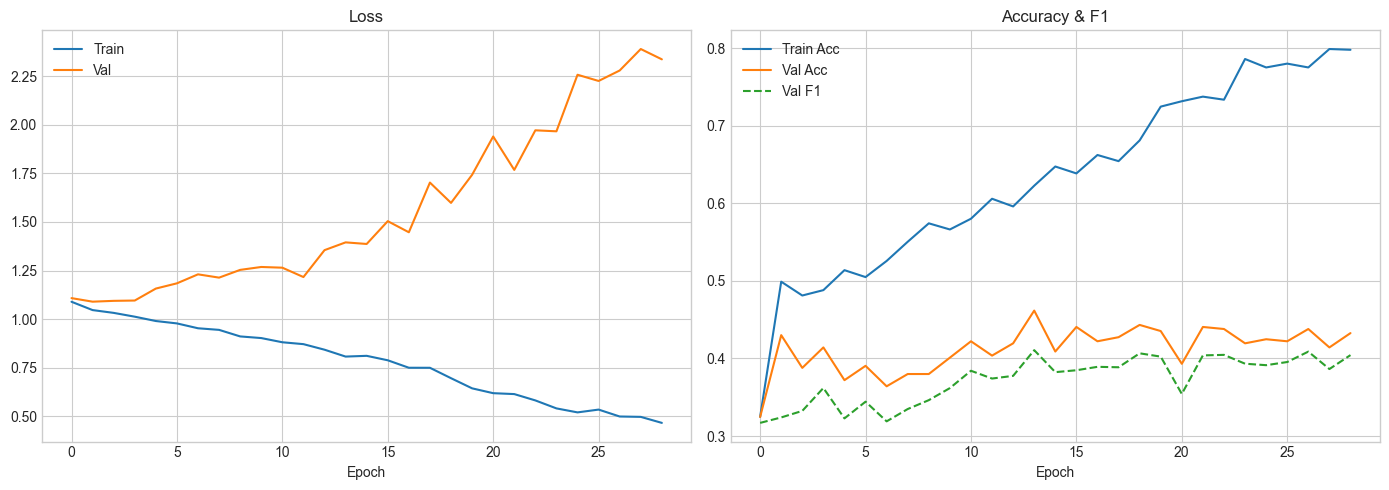

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].set_xlabel('Epoch')
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].plot(history['val_f1'], label='Val F1', linestyle='--')
axes[1].set_title('Accuracy & F1')
axes[1].legend()
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_training_curves.png', dpi=150)
plt.show()

## 7. Confusion Matrix and Top-2 Accuracy

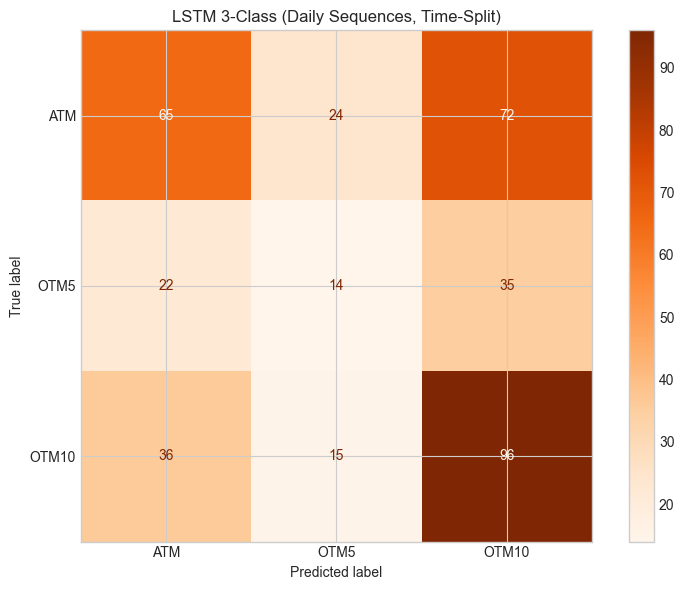

Top-1 Accuracy: 0.4617
Top-2 Accuracy: 0.6966


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['ATM', 'OTM5', 'OTM10'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('LSTM 3-Class (Daily Sequences, Time-Split)')
plt.tight_layout()
plt.savefig('../reports/figures/lstm_confusion_matrix.png', dpi=150)
plt.show()

# Top-2 accuracy
test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_sc), torch.LongTensor(y_test)),
    batch_size=64, shuffle=False
)
model.eval()
all_proba = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        proba = torch.softmax(model(xb), dim=1)
        all_proba.extend(proba.cpu().numpy())
all_proba = np.array(all_proba)

top2 = np.argsort(all_proba, axis=1)[:, -2:]
top2_correct = np.array([labels[i] in top2[i] for i in range(len(labels))])
print(f"Top-1 Accuracy: {acc:.4f}")
print(f"Top-2 Accuracy: {top2_correct.mean():.4f}")

## 8. Comparison with Tree Models

Model Comparison:
                           Model  Accuracy  Macro F1
           9-class RF (baseline)  0.372800  0.358100
          9-class XGB (baseline)  0.387100  0.355600
  6-class RF (tuned, time-split)  0.285000  0.226100
 6-class XGB (tuned, time-split)  0.240100  0.192800
6-class LGBM (tuned, time-split)  0.216400  0.176500
  6-class Two-Stage (time-split)  0.229600  0.166700
     LSTM daily-seq (time-split)  0.461741  0.410708


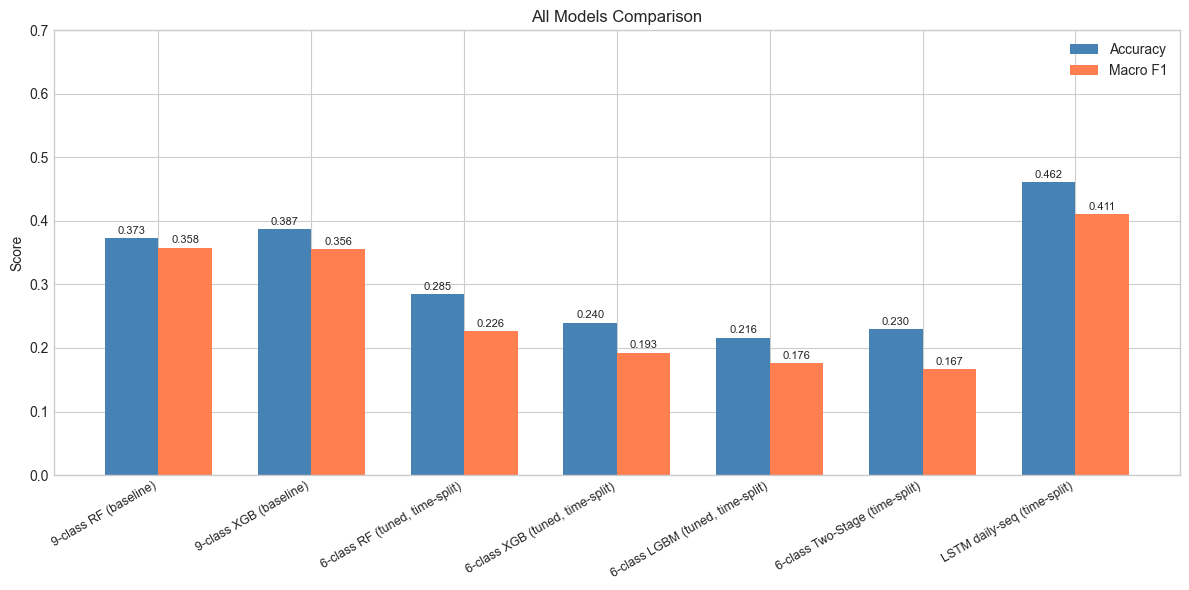

In [12]:
# Load previous results
try:
    prev = pd.read_csv(PROCESSED / 'improved_results.csv')
except:
    prev = pd.DataFrame(columns=['Model', 'Accuracy', 'Macro F1'])

lstm_row = pd.DataFrame({
    'Model': ['LSTM daily-seq (time-split)'],
    'Accuracy': [acc],
    'Macro F1': [f1m]
})

all_results = pd.concat([prev, lstm_row], ignore_index=True)

print("Model Comparison:")
print(all_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_results))
w = 0.35
b1 = ax.bar(x - w/2, all_results['Accuracy'], w, label='Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, all_results['Macro F1'], w, label='Macro F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('All Models Comparison')
ax.legend()
ax.set_ylim(0, 0.7)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Model

In [13]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': n_feat, 'hidden_size': 64, 'num_layers': 2,
    'num_classes': 3, 'seq_length': SEQ_LENGTH,
    'feature_cols': feature_cols,
    'split_date': str(pd.Timestamp(split_date).date()),
    'approach': 'daily sequences, time-based split, class weights, 3-class moneyness',
}, MODELS / 'lstm_3class_daily.pt')

all_results.to_csv(PROCESSED / 'all_model_results.csv', index=False)

print("Model saved.")
print(f"\nLSTM daily-seq: Acc={acc:.4f}, F1={f1m:.4f}, Top-2={top2_correct.mean():.4f}")

Model saved.

LSTM daily-seq: Acc=0.4617, F1=0.4107, Top-2=0.6966
